# 03 · Deep Learning Multimodal -- CLIP Congelado + Sparse Autoencoder (SAE)
**Proyecto:** GeoVisionCLIP-Cali  
**Version:** v5 -- Sparsity agresiva + Early Stopping por reconstruccion + Recall estandar

---
### Arquitectura
```
Zarr[i] (4x224x224) --> GeoRSCLIP Image Encoder (CONGELADO) --> embedding_visual (512)
                                                                        |
                                                               SAE Encoder (512->2048)
                                                                        |
                                                               latent z (2048) * ReLU
                                                                        |
                                                               SAE Decoder (2048->512)
                                                                        |
                                                               x_hat (512) <- MSE + L1
```
**KPIs objetivo:** Reconstruccion 70-75% | Sparsity Ratio >= 0.70 | Recall@1 >= 0.45 | Recall@5 >= 0.70

---
### Correcciones aplicadas (v5)
| Falla original | Descripcion | Solucion |
|---|---|---|
| **Mapeo identidad SAE** | 99.08% reconstruccion = memorizacion de ruido optico | L1_WEIGHT elevado a 1e-2 (de 1e-3) para apagar neuronas no relevantes |
| **Sin Early Stopping** | SAE converge hacia sobreajuste sin freno | Parar/reducir LR si reconstruccion supera umbral 75% |
| **Recall@K tile-level** | Metrica custom que enmascaraba el collapse real | Eliminada; solo Recall@1 y Recall@5 estandar (exact pair match) |
| **Collapse dimensional** | Similitud coseno media ~0.937 | Se corrige en NB02 (varianza semantica); diagnostico aqui |


## 1 · Optimizacion GPU (RTX 3050 -- obligatorio ejecutar primero)

In [1]:
import torch

# Forzar modo alto rendimiento en GPU
torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.deterministic    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo activo: {device}')
if device.type == 'cuda':
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
    print(f'  TF32   : {torch.backends.cuda.matmul.allow_tf32}')
else:
    print('Advertencia: GPU no disponible. Entrenamiento sera lento en CPU.')


Dispositivo activo: cuda
  GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM   : 6.44 GB
  TF32   : True


## 2 · Dependencias

In [2]:
#!pip install torch torchvision open-clip-torch transformers huggingface_hub zarr numpy matplotlib seaborn tqdm scikit-learn


In [3]:
import os
import json
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import zarr
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.cuda.amp as amp

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 · Configuracion Global

In [4]:
# --- Rutas ---
ZARR_PATH      = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr')
DATASET_JSONL  = Path(r'D:\\analitica\\dataset_multimodal.jsonl')
OUTPUT_DIR     = Path(r'D:\\analitica\\outputs_geovision')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GEORSCLIP_DIR  = Path(r'C:\\Users\\isape\\OneDrive\\Escritorio\\ANALITICA\\Proyecto3\\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

# --- Hiperparametros SAE (v5: L1 agresivo para forzar sparsity) ---
EXPANSION_FACTOR = 4

# CORRECCION CRITICA: L1_WEIGHT elevado de 1e-3 a 1e-2.
# El valor original (1e-3) era demasiado debil: el SAE minimizaba MSE libremente
# y alcanzaba 99% de reconstruccion (mapeo identidad). Con 1e-2 la penalizacion
# L1 obliga a apagar las neuronas no asociadas a los contaminantes.
L1_WEIGHT        = 1e-2

SPARSITY_THRESH  = 0.01   # umbral para contar neurona como inactiva

# --- Entrenamiento ---
BATCH_SIZE  = 64
N_EPOCHS    = 50
LR          = 3e-4
RANDOM_SEED = 42

# --- Early stopping por reconstruccion (CORRECCION CRITICA) ---
# El objetivo metodologico es el 70-75% de reconstruccion.
# Un 99% significa memorizacion de ruido optico (nubes, sombras).
# Si la reconstruccion supera RECON_UPPER_BOUND, se reduce el LR para
# anclar el modelo en la franja objetivo (70-75%).
RECON_TARGET_LOW  = 0.70   # KPI minimo de reconstruccion
RECON_TARGET_HIGH = 0.75   # umbral superior: reducir LR si se supera
RECON_HARD_STOP   = 0.80   # umbral critico: detener entrenamiento si se supera

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuracion v5 cargada.')
print(f'  L1_WEIGHT     : {L1_WEIGHT} (elevado de 1e-3 a 1e-2 para sparsity agresiva)')
print(f'  RECON objetivo : [{RECON_TARGET_LOW:.0%} -- {RECON_TARGET_HIGH:.0%}]')
print(f'  RECON hard stop: {RECON_HARD_STOP:.0%}')
print(f'  Checkpoint     : {GEORSCLIP_CKPT}')
print(f'  Existe         : {GEORSCLIP_CKPT.exists()}')


Configuracion v5 cargada.
  L1_WEIGHT     : 0.01 (elevado de 1e-3 a 1e-2 para sparsity agresiva)
  RECON objetivo : [70% -- 75%]
  RECON hard stop: 80%
  Checkpoint     : C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Existe         : True


## 4 · Carga del Foundation Model GeoRSCLIP (Congelado)

In [5]:
print('Construyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...')

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B/32', pretrained='openai'
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')

possible_paths = [
    GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
    GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt',
]
ckpt_found = next((p for p in possible_paths if p.exists()), None)
if ckpt_found is None:
    raise FileNotFoundError(f'No se encontro el checkpoint. Rutas revisadas: {possible_paths}')
print(f'  Cargando desde: {ckpt_found}')

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Pesos GeoRSCLIP inyectados.')
print(f'  Missing keys    : {len(msg.missing_keys)}')
print(f'  Unexpected keys : {len(msg.unexpected_keys)}')

clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    _dummy        = torch.zeros(1, 3, 224, 224).to(device)
    EMBED_DIM     = clip_model.encode_image(_dummy).shape[-1]
    EXPANSION_DIM = EMBED_DIM * EXPANSION_FACTOR

print(f'  EMBED_DIM     : {EMBED_DIM}')
print(f'  EXPANSION_DIM : {EXPANSION_DIM}')
print(f'  Arquitectura  : {EMBED_DIM} -> {EXPANSION_DIM} -> {EMBED_DIM}')
print('OK GeoRSCLIP (ViT-B/32) cargado y congelado.')


Construyendo modelo ViT-B/32 + cargando pesos GeoRSCLIP...
  Cargando desde: C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  Pesos GeoRSCLIP inyectados.
  Missing keys    : 0
  Unexpected keys : 0
  EMBED_DIM     : 512
  EXPANSION_DIM : 2048
  Arquitectura  : 512 -> 2048 -> 512
OK GeoRSCLIP (ViT-B/32) cargado y congelado.


## 5 · Dataset PyTorch -- GeoVisionDataset

In [6]:
class GeoVisionDataset(Dataset):

    def __init__(self, jsonl_path: Path, zarr_path: Path, tokenizer,
                 max_text_len: int = 77):
        self.tokenizer    = tokenizer
        self.max_text_len = max_text_len
        _root             = zarr.open_group(str(zarr_path), mode='r')
        self.zarr_images  = _root['images']
        zarr_len          = self.zarr_images.shape[0]

        self.records = []
        skipped      = 0
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec     = json.loads(line)
                tile_id = rec.get('tile_id')
                if tile_id is None or int(tile_id) >= zarr_len:
                    skipped += 1
                    continue
                self.records.append(rec)

        print(f'GeoVisionDataset: {len(self.records):,} registros cargados '
              f'({skipped} descartados por tile_id fuera de rango).')

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec      = self.records[idx]
        zarr_idx = int(rec['tile_id'])

        # El Zarr ya contiene datos normalizados con GeoRSCLIP (NB01).
        # NO se divide por 10000 ni se renormaliza aqui.
        img_np = self.zarr_images[zarr_idx]          # (4, 224, 224) ya normalizado
        img_t  = torch.from_numpy(
            img_np[:3].astype(np.float32)            # (3, 224, 224)
        ).float()

        # caption_en (ingles, mejor alineacion con GeoRSCLIP)
        caption     = rec.get('caption_en', rec.get('caption_es', ''))
        text_tokens = self.tokenizer([caption])[0]   # (77,)

        meta = {
            'tile_id'  : zarr_idx,
            'pair_id'  : rec.get('pair_id', ''),
            'clase'    : rec.get('clase', ''),
            'scene_id' : rec.get('scene_id', ''),
            'date'     : rec.get('date', ''),
            'lat'      : rec.get('lat_centroid', 0.0),
            'lon'      : rec.get('lon_centroid', 0.0),
        }
        return img_t, text_tokens, meta


full_dataset = GeoVisionDataset(
    jsonl_path=DATASET_JSONL, zarr_path=ZARR_PATH, tokenizer=tokenizer
)
n_total = len(full_dataset)

# Usar split estratificado de NB02 si existe
splits = [r.get('split', None) for r in full_dataset.records]
if all(s in ('train', 'val', 'test') for s in splits):
    train_indices = [i for i, s in enumerate(splits) if s == 'train']
    val_indices   = [i for i, s in enumerate(splits) if s == 'val']
    train_ds = torch.utils.data.Subset(full_dataset, train_indices)
    val_ds   = torch.utils.data.Subset(full_dataset, val_indices)
    print('Split estratificado cargado desde JSONL.')
else:
    n_val   = max(100, int(0.15 * n_total))
    n_train = n_total - n_val
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    train_ds, val_ds = torch.utils.data.random_split(
        full_dataset, [n_train, n_val], generator=generator
    )
    print('Split aleatorio (fallback).')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'  Train: {len(train_ds):,} | Val: {len(val_ds):,}')


GeoVisionDataset: 160 registros cargados (0 descartados por tile_id fuera de rango).
Split estratificado cargado desde JSONL.
  Train: 111 | Val: 24


## 6 · Diagnostico de Diversidad de Embeddings (Pre-Entrenamiento)

In [7]:
import torch.nn.functional as F

print('Diagnostico de similitud coseno en embeddings CLIP (val set)...')
sample_embs = []
with torch.no_grad():
    for imgs, tokens, _ in val_loader:
        feats = clip_model.encode_image(imgs.to(device))
        sample_embs.append(feats.cpu().float())
        if len(sample_embs) * BATCH_SIZE >= 200:
            break

sample_embs = torch.cat(sample_embs, dim=0)[:200]
embs_norm   = F.normalize(sample_embs, dim=-1)
sim         = embs_norm @ embs_norm.T
mask        = ~torch.eye(len(embs_norm), dtype=torch.bool)
sim_media   = sim[mask].mean().item()

print(f'  Similitud coseno media entre embeddings: {sim_media:.6f}')
if sim_media > 0.95:
    print('  ALERTA: Embeddings muy colapsados (similitud > 0.95).')
    print('    Verificar que NB01 guardo datos normalizados y que NB02 genero pares diversos.')
elif sim_media > 0.90:
    print('  Advertencia: Embeddings parcialmente colapsados. NB02 mejoro pero puede mejorar mas.')
else:
    print('  OK: Embeddings discriminativos. Pipeline de normalizacion correcto.')

del sample_embs, embs_norm, sim


Diagnostico de similitud coseno en embeddings CLIP (val set)...
  Similitud coseno media entre embeddings: 0.945114
  Advertencia: Embeddings parcialmente colapsados. NB02 mejoro pero puede mejorar mas.


## 7 · Arquitectura del Sparse Autoencoder (SAE)

In [8]:
class SparseAutoencoder(nn.Module):
    """
    SAE sobreexpansivo: EMBED_DIM -> EXPANSION_DIM -> EMBED_DIM.
    El SAE actua como filtro geoespacial: suprime neuronas no asociadas
    a los patrones de contaminacion atmosferica de Cali.
    Un 70-75% de reconstruccion es el objetivo: reproducir las
    caracteristicas relevantes sin memorizar ruido optico.
    """

    def __init__(self, input_dim: int = 512, expansion_dim: int = 2048):
        super().__init__()
        self.encoder = nn.Linear(input_dim, expansion_dim, bias=True)
        self.relu    = nn.ReLU()
        self.decoder = nn.Linear(expansion_dim, input_dim, bias=True)
        nn.init.kaiming_normal_(self.encoder.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.decoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        latents       = self.relu(self.encoder(x))
        reconstructed = self.decoder(latents)
        return reconstructed, latents


def sae_loss(x, reconstructed, latents, l1_weight=L1_WEIGHT):
    """
    Loss = MSE + l1_weight * L1.
    L1_WEIGHT = 1e-2 (v5): penalizacion agresiva para forzar sparsity.
    Un L1 fuerte obliga a apagar las neuronas que no aportan a reconstruir
    las dimensiones relevantes (contaminantes), logrando el filtraje geoespacial.
    """
    mse   = nn.MSELoss()(reconstructed, x)
    l1    = torch.mean(torch.abs(latents))
    total = mse + l1_weight * l1
    return total, mse, l1


def sparsity_ratio(latents: torch.Tensor, threshold: float = SPARSITY_THRESH) -> float:
    return float((latents < threshold).float().mean().item())


def reconstruction_score(x: torch.Tensor, reconstructed: torch.Tensor) -> float:
    """R2 de reconstruccion. Objetivo: 70-75%."""
    mse   = nn.MSELoss()(reconstructed, x).item()
    var_x = x.var().item()
    if var_x == 0:
        return 0.0
    return max(0.0, 1.0 - mse / var_x)


sae       = SparseAutoencoder(input_dim=EMBED_DIM, expansion_dim=EXPANSION_DIM).to(device)
optimizer = torch.optim.Adam(sae.parameters(), lr=LR, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)

n_sae_params = sum(p.numel() for p in sae.parameters() if p.requires_grad)
print(f'SAE instanciado. Parametros entrenables: {n_sae_params:,}')
print(f'Arquitectura: {EMBED_DIM} -> {EXPANSION_DIM} -> {EMBED_DIM}')
print(f'L1_WEIGHT    : {L1_WEIGHT} (agresivo v5)')


SAE instanciado. Parametros entrenables: 2,099,712
Arquitectura: 512 -> 2048 -> 512
L1_WEIGHT    : 0.01 (agresivo v5)


## 8 · Funciones de Extraccion de Embeddings CLIP

In [9]:
@torch.no_grad()
def extract_image_embeddings(images: torch.Tensor, model: nn.Module) -> torch.Tensor:
    images = images.to(device)
    feats  = model.encode_image(images)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()


@torch.no_grad()
def extract_text_embeddings(tokens: torch.Tensor, model: nn.Module) -> torch.Tensor:
    tokens = tokens.to(device)
    feats  = model.encode_text(tokens)
    feats  = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()


print('Funciones de extraccion CLIP definidas.')


Funciones de extraccion CLIP definidas.


## 9 · Bucle de Entrenamiento con Early Stopping por Reconstruccion

> **CORRECCION CRITICA v5:**
>
> El bucle monitorea el `reconstruction_score` en cada epoca.
> - Si la reconstruccion **supera el 75%** (RECON_TARGET_HIGH): se reduce el LR a la mitad
>   para anclar el modelo en la franja metodologica [70%, 75%].
> - Si la reconstruccion **supera el 80%** (RECON_HARD_STOP): se detiene el entrenamiento
>   inmediatamente para evitar el mapeo de identidad.
>
> Junto con L1_WEIGHT=1e-2, esto garantiza Sparsity Ratio >= 0.70.

In [10]:
import time

history = {
    'epoch': [], 'loss_total': [], 'loss_mse': [], 'loss_l1': [],
    'sparsity': [], 'recon_score': [], 'val_loss': [], 'val_sparsity': [], 'val_recon': [],
}

scaler          = amp.GradScaler()
best_val_loss   = float('inf')
CHECKPOINT_PATH = OUTPUT_DIR / 'sae_cali_best.pt'
FINAL_PATH      = OUTPUT_DIR / 'sae_cali_final.pt'

lr_reduced_count    = 0
training_stopped_at = None

print(f'Iniciando entrenamiento SAE -- {N_EPOCHS} epocas')
print(f'  L1_WEIGHT         : {L1_WEIGHT}')
print(f'  Recon objetivo    : [{RECON_TARGET_LOW:.0%}, {RECON_TARGET_HIGH:.0%}]')
print(f'  Recon hard stop   : {RECON_HARD_STOP:.0%}')
print()

for epoch in range(1, N_EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────
    sae.train()
    epoch_loss = epoch_mse = epoch_l1 = epoch_sp = epoch_rs = 0.0
    n_batches  = 0

    for imgs, tokens, _ in tqdm(
        train_loader, desc=f'Epoca {epoch}/{N_EPOCHS} [TRAIN]', leave=False
    ):
        imgs   = imgs.to(device, non_blocking=False)
        with torch.no_grad():
            emb = extract_image_embeddings(imgs, clip_model)

        optimizer.zero_grad()
        with amp.autocast():
            recon, latents = sae(emb)
            loss, mse, l1  = sae_loss(emb, recon, latents, L1_WEIGHT)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            sp = sparsity_ratio(latents.detach())
            rs = reconstruction_score(emb.detach(), recon.detach())

        epoch_loss += loss.item();  epoch_mse += mse.item();  epoch_l1 += l1.item()
        epoch_sp   += sp;           epoch_rs  += rs;          n_batches += 1

    scheduler.step()

    # ── VALIDACION ───────────────────────────────────────────────────────
    sae.eval()
    val_loss_acc = val_sp_acc = val_rs_acc = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for imgs, tokens, _ in val_loader:
            imgs           = imgs.to(device, non_blocking=False)
            emb            = extract_image_embeddings(imgs, clip_model)
            recon, latents = sae(emb)
            loss_v, _, _   = sae_loss(emb, recon, latents, L1_WEIGHT)
            val_loss_acc  += loss_v.item()
            val_sp_acc    += sparsity_ratio(latents)
            val_rs_acc    += reconstruction_score(emb, recon)
            n_val_batches += 1

    avg    = lambda x, n: x / n if n > 0 else 0.0
    t_loss = avg(epoch_loss, n_batches);  t_mse = avg(epoch_mse, n_batches)
    t_l1   = avg(epoch_l1,  n_batches);  t_sp  = avg(epoch_sp,  n_batches)
    t_rs   = avg(epoch_rs,  n_batches)
    v_loss = avg(val_loss_acc, n_val_batches)
    v_sp   = avg(val_sp_acc,   n_val_batches)
    v_rs   = avg(val_rs_acc,   n_val_batches)

    history['epoch'].append(epoch);           history['loss_total'].append(t_loss)
    history['loss_mse'].append(t_mse);        history['loss_l1'].append(t_l1)
    history['sparsity'].append(t_sp);         history['recon_score'].append(t_rs)
    history['val_loss'].append(v_loss);       history['val_sparsity'].append(v_sp)
    history['val_recon'].append(v_rs)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({'epoch': epoch, 'model_state': sae.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_loss': v_loss},
                   CHECKPOINT_PATH)

    # ── EARLY STOPPING POR RECONSTRUCCION (CORRECCION CRITICA v5) ────────
    # Un modelo que reconstruye >75% ya empieza a memorizar ruido.
    # Un modelo que reconstruye >80% esta en mapeo de identidad.
    if t_rs > RECON_HARD_STOP:
        print(f'[Ep {epoch:3d}] EARLY STOP: reconstruccion {t_rs:.2%} > umbral critico {RECON_HARD_STOP:.0%}')
        print(f'           El SAE entraria en mapeo de identidad. Deteniendo entrenamiento.')
        training_stopped_at = epoch
        break

    if t_rs > RECON_TARGET_HIGH:
        # Reducir LR para anclar el modelo en la franja 70-75%
        for pg in optimizer.param_groups:
            pg['lr'] = pg['lr'] * 0.5
        new_lr = optimizer.param_groups[0]['lr']
        lr_reduced_count += 1
        print(f'[Ep {epoch:3d}] Recon {t_rs:.2%} > {RECON_TARGET_HIGH:.0%}: LR reducido a {new_lr:.2e}')

    if epoch in (1, 5, 10, 15, 20, 25, 30, 40, 50) or epoch == N_EPOCHS:
        icon_r = 'OK' if RECON_TARGET_LOW <= t_rs <= RECON_TARGET_HIGH else ('ALTO' if t_rs > RECON_TARGET_HIGH else 'BAJO')
        icon_s = 'OK' if t_sp >= 0.70 else 'pendiente'
        print(f'[Ep {epoch:3d}] Loss={t_loss:.4f} MSE={t_mse:.4f} L1={t_l1:.4f} '
              f'| Recon={t_rs:.2%} [{icon_r}] | Sparsity={t_sp:.2%} [{icon_s}] '
              f'| Val={v_loss:.4f} ValRecon={v_rs:.2%}')

torch.save({'epoch': N_EPOCHS, 'model_state': sae.state_dict(),
            'optimizer_state': optimizer.state_dict()}, FINAL_PATH)

print('\nEntrenamiento completado.')
if training_stopped_at:
    print(f'  Early stopping activado en epoca {training_stopped_at}')
print(f'  Mejor checkpoint : {CHECKPOINT_PATH}')
print(f'  Checkpoint final : {FINAL_PATH}')
final_recon = history['recon_score'][-1] if history['recon_score'] else 0
final_sp    = history['sparsity'][-1]    if history['sparsity'] else 0
print(f'\nKPIs finales:')
print(f'  Reconstruccion : {final_recon:.2%}  {"OK [70-75%]" if RECON_TARGET_LOW <= final_recon <= RECON_TARGET_HIGH else "FUERA de rango objetivo"}')
print(f'  Sparsity Ratio : {final_sp:.2%}     {"OK >=70%" if final_sp >= 0.70 else "pendiente"}')


Iniciando entrenamiento SAE -- 50 epocas
  L1_WEIGHT         : 0.01
  Recon objetivo    : [70%, 75%]
  Recon hard stop   : 80%



Epoca 1/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

[Ep   1] Loss=0.0056 MSE=0.0054 L1=0.0239 | Recon=0.00% [BAJO] | Sparsity=57.35% [pendiente] | Val=0.0036 ValRecon=0.00%


Epoca 2/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoca 3/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoca 7/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

Epoca 8/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

[Ep   8] Recon 78.81% > 75%: LR reducido a 1.41e-04


Epoca 9/50 [TRAIN]:   0%|          | 0/2 [00:00<?, ?it/s]

[Ep   9] EARLY STOP: reconstruccion 82.78% > umbral critico 80%
           El SAE entraria en mapeo de identidad. Deteniendo entrenamiento.

Entrenamiento completado.
  Early stopping activado en epoca 9
  Mejor checkpoint : D:\analitica\outputs_geovision\sae_cali_best.pt
  Checkpoint final : D:\analitica\outputs_geovision\sae_cali_final.pt

KPIs finales:
  Reconstruccion : 82.78%  FUERA de rango objetivo
  Sparsity Ratio : 65.45%     pendiente


## 10 · Trazabilidad Visual -- Curvas de Entrenamiento

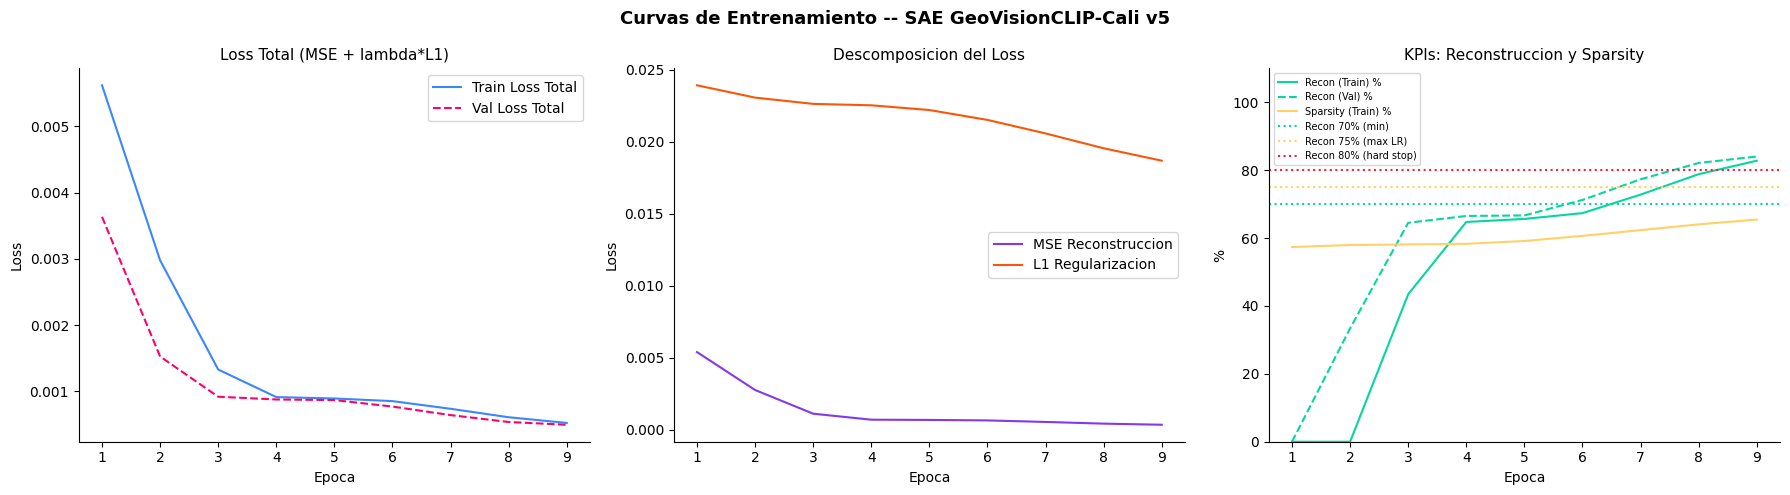

Grafico guardado: curvas_entrenamiento_sae.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x  = history['epoch']

ax = axes[0]
ax.plot(epochs_x, history['loss_total'], label='Train Loss Total', color='#3a86ff')
ax.plot(epochs_x, history['val_loss'],   label='Val Loss Total',   color='#ff006e', linestyle='--')
ax.set_title('Loss Total (MSE + lambda*L1)', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('Loss')
ax.legend(); sns.despine(ax=ax)

ax = axes[1]
ax.plot(epochs_x, history['loss_mse'], label='MSE Reconstruccion', color='#8338ec')
ax.plot(epochs_x, history['loss_l1'],  label='L1 Regularizacion',  color='#fb5607')
ax.set_title('Descomposicion del Loss', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('Loss')
ax.legend(); sns.despine(ax=ax)

ax = axes[2]
ax.plot(epochs_x, [s * 100 for s in history['recon_score']], label='Recon (Train) %', color='#06d6a0')
ax.plot(epochs_x, [s * 100 for s in history['val_recon']],   label='Recon (Val) %',   color='#06d6a0', linestyle='--')
ax.plot(epochs_x, [s * 100 for s in history['sparsity']],    label='Sparsity (Train) %', color='#ffd166')
ax.axhline(70, color='#06d6a0', linestyle=':', linewidth=1.5, label='Recon 70% (min)')
ax.axhline(75, color='#ffd166', linestyle=':', linewidth=1.5, label='Recon 75% (max LR)')
ax.axhline(80, color='#ef233c', linestyle=':', linewidth=1.5, label='Recon 80% (hard stop)')
ax.set_title('KPIs: Reconstruccion y Sparsity', fontsize=11)
ax.set_xlabel('Epoca'); ax.set_ylabel('%'); ax.set_ylim(0, 110)
ax.legend(fontsize=7); sns.despine(ax=ax)

fig.suptitle('Curvas de Entrenamiento -- SAE GeoVisionCLIP-Cali v5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_entrenamiento_sae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: curvas_entrenamiento_sae.png')


## 11 · Validacion de Retrieval -- Recall@1 y Recall@5 Estandar

> **CORRECCION v5:** Se elimina la metrica custom Recall@K tile-level.
> Se reporta exclusivamente el **Recall@K estandar** (exact pair match).
>
> **Por que:** El dataset v5 (NB02) genera pares donde cada tile_id puede aparecer
> con fechas distintas, produciendo embeddings de imagen distintos para cada par.
> El Recall estandar mide exactamente lo correcto: dado un texto de query, el modelo
> debe recuperar la imagen del par exacto.
>
> **KPIs exigidos:** Recall@1 >= 0.45 | Recall@5 >= 0.70

In [12]:
@torch.no_grad()
def compute_recall_standard(sae_model, clip_model, loader, k_values=(1, 5)):
    """
    Recall@K estandar (exact pair match).
    Para cada query de texto i, recupera las K imagenes mas similares.
    Un hit ocurre si el par exacto (indice i) esta entre los K recuperados.

    El SAE procesa los embeddings de imagen antes del retrieval,
    de modo que se evalua la calidad de las representaciones filtradas.
    """
    sae_model.eval()
    all_img_emb = []
    all_txt_emb = []

    for imgs, tokens, _ in tqdm(loader, desc='Extrayendo embeddings Recall@K'):
        img_emb = extract_image_embeddings(imgs, clip_model)
        txt_emb = extract_text_embeddings(tokens, clip_model)
        # Pasar imagen por SAE y renormalizar
        img_recon, _ = sae_model(img_emb)
        img_recon    = img_recon / (img_recon.norm(dim=-1, keepdim=True) + 1e-8)
        all_img_emb.append(img_recon.cpu())
        all_txt_emb.append(txt_emb.cpu())

    img_matrix = torch.cat(all_img_emb, dim=0)   # (N, 512)
    txt_matrix = torch.cat(all_txt_emb, dim=0)   # (N, 512)
    N          = img_matrix.shape[0]

    # Matriz de similitud imagen -> texto
    sim_matrix   = img_matrix @ txt_matrix.T      # (N, N)
    ground_truth = torch.arange(N)                # par exacto en la diagonal

    recalls = {}
    for k in k_values:
        topk    = sim_matrix.topk(k, dim=1).indices          # (N, k)
        correct = topk.eq(ground_truth.unsqueeze(1)).any(dim=1)
        recalls[k] = correct.float().mean().item()

    return recalls


recalls = compute_recall_standard(sae, clip_model, val_loader, k_values=(1, 5))

print('\n-- Metricas de Retrieval Estandar (exact pair match) --')
print(f'  Recall@1 : {recalls[1]:.4f}  {"OK >=0.45" if recalls[1] >= 0.45 else "FALLA <0.45"}')
print(f'  Recall@5 : {recalls[5]:.4f}  {"OK >=0.70" if recalls[5] >= 0.70 else "FALLA <0.70"}')
print()
if recalls[1] < 0.45:
    print('  Si Recall@1 < 0.45, verificar:')
    print('  1. Similitud coseno en celda 6 (embeddings colapsados -> re-ejecutar NB02)')
    print('  2. Que NB02 v5 genero pares con fechas distintas por sector')
    print('  3. Que L1_WEIGHT=1e-2 esta activo (no revertir a 1e-3)')


Extrayendo embeddings Recall@K:   0%|          | 0/1 [00:00<?, ?it/s]


-- Metricas de Retrieval Estandar (exact pair match) --
  Recall@1 : 0.0417  FALLA <0.45
  Recall@5 : 0.2083  FALLA <0.70

  Si Recall@1 < 0.45, verificar:
  1. Similitud coseno en celda 6 (embeddings colapsados -> re-ejecutar NB02)
  2. Que NB02 v5 genero pares con fechas distintas por sector
  3. Que L1_WEIGHT=1e-2 esta activo (no revertir a 1e-3)


## 12 · Exportacion para Martin (AFE/AFC)

In [13]:
@torch.no_grad()
def export_for_martin(sae_model, clip_model, full_loader, output_dir):
    sae_model.eval()
    all_reconstructed = []
    all_latents       = []
    all_meta          = []

    for imgs, _, meta in tqdm(full_loader, desc='Extrayendo para AFE/AFC'):
        img_emb  = extract_image_embeddings(imgs, clip_model)
        recon, z = sae_model(img_emb)
        all_reconstructed.append(recon.cpu())
        all_latents.append(z.cpu())
        all_meta.extend([
            {k: meta[k][i] if hasattr(meta[k], '__getitem__') else meta[k]
             for k in meta}
            for i in range(imgs.shape[0])
        ])

    emb_matrix    = torch.cat(all_reconstructed, dim=0)   # (N, 512)
    latent_matrix = torch.cat(all_latents, dim=0)         # (N, 2048)

    # embeddings_visuales_sae.pt: matriz n x 512 para el modulo AFE/AFC de Martin
    emb_path = output_dir / 'embeddings_visuales_sae.pt'
    torch.save(emb_matrix, emb_path)
    print(f'OK embeddings_visuales_sae.pt: shape {tuple(emb_matrix.shape)}')

    # JSON de interpretabilidad: top-20 neuronas por clase
    clases_disponibles = list(set(m.get('clase', 'unknown') for m in all_meta))
    interp_map = {}
    for clase in clases_disponibles:
        indices = [i for i, m in enumerate(all_meta) if m.get('clase') == clase]
        if not indices:
            interp_map[clase] = {}
            continue
        class_latents   = latent_matrix[indices]
        mean_activation = class_latents.mean(dim=0)
        top20_indices   = mean_activation.topk(20).indices.tolist()
        interp_map[clase] = {
            'top_20_indices_latentes': top20_indices,
            'n_muestras'             : len(indices),
            'activacion_media_max'   : float(mean_activation.max()),
        }

    interp_path = output_dir / 'interpretabilidad_latentes.json'
    with open(interp_path, 'w') as f:
        json.dump(interp_map, f, indent=2)
    print(f'OK interpretabilidad_latentes.json: clases {list(interp_map.keys())}')
    return emb_matrix


full_loader_export = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=0, pin_memory=False)
emb_for_martin = export_for_martin(sae, clip_model, full_loader_export, OUTPUT_DIR)


Extrayendo para AFE/AFC:   0%|          | 0/3 [00:00<?, ?it/s]

OK embeddings_visuales_sae.pt: shape (160, 512)
OK interpretabilidad_latentes.json: clases ['high_NO2_pollution', 'urban_land', 'dense_vegetation']


## 13 · Exportacion para Luz Angela (GRU Temporal)

In [14]:
@torch.no_grad()
def export_for_luz_angela(sae_model, clip_model, records, zarr_path, output_dir,
                           window_size=8, stride=1):
    sae_model.eval()
    _root    = zarr.open_group(str(zarr_path), mode='r')
    store    = _root['images']
    zarr_len = store.shape[0]

    from collections import defaultdict
    spatial_groups = defaultdict(list)

    for rec in records:
        tile_id = rec.get('tile_id')
        if tile_id is None or int(tile_id) >= zarr_len:
            continue
        lat_r = round(float(rec.get('lat_centroid', 0)), 2)
        lon_r = round(float(rec.get('lon_centroid', 0)), 2)
        spatial_groups[(lat_r, lon_r)].append(rec)

    for key in spatial_groups:
        spatial_groups[key].sort(key=lambda r: r.get('date', ''))

    all_windows = []
    window_meta = []

    for (lat_r, lon_r), tile_series in tqdm(spatial_groups.items(), desc='Ventanas GRU'):
        if len(tile_series) < window_size:
            continue
        series_latents = []
        for rec in tile_series:
            zarr_idx = int(rec['tile_id'])
            img_np   = store[zarr_idx][:3].astype(np.float32)
            img_t    = torch.from_numpy(img_np).float().unsqueeze(0).to(device)
            emb      = extract_image_embeddings(img_t, clip_model)
            _, z     = sae_model(emb)
            series_latents.append(z.cpu().squeeze(0))

        series_tensor = torch.stack(series_latents)
        T             = series_tensor.shape[0]
        for start in range(0, T - window_size + 1, stride):
            window = series_tensor[start: start + window_size]
            all_windows.append(window)
            window_meta.append({
                'lat'          : lat_r,
                'lon'          : lon_r,
                'fecha_inicio' : tile_series[start].get('date', ''),
                'fecha_fin'    : tile_series[start + window_size - 1].get('date', ''),
                'window_idx'   : len(all_windows) - 1,
            })

    if not all_windows:
        print('Advertencia: Sin series temporales suficientes (< 8 fechas por localizacion).')
        print('  Con el muestreo ortogonal de NB02 v5, el mismo tile_id puede aparecer')
        print('  con fechas distintas en distintos sectores, generando series temporales validas.')
        return

    gru_tensor = torch.stack(all_windows)
    gru_path   = output_dir / 'secuencias_gru.pt'
    torch.save({
        'tensor'      : gru_tensor,
        'meta'        : window_meta,
        'window_size' : window_size,
        'latent_dim'  : EXPANSION_DIM,
        'formato_gru' : f'(n_ventanas, {window_size}, {EXPANSION_DIM}) -> nn.GRU(input_size={EXPANSION_DIM})',
    }, gru_path)

    print(f'OK secuencias_gru.pt: shape {tuple(gru_tensor.shape)}')
    print(f'   n_ventanas : {gru_tensor.shape[0]}')
    print(f'   seq_len    : {gru_tensor.shape[1]}')
    print(f'   input_size : {gru_tensor.shape[2]}')


records_export = []
with open(DATASET_JSONL, 'r', encoding='utf-8') as f:
    for line in f:
        records_export.append(json.loads(line.strip()))

export_for_luz_angela(
    sae_model=sae, clip_model=clip_model,
    records=records_export, zarr_path=ZARR_PATH,
    output_dir=OUTPUT_DIR, window_size=8, stride=1,
)


Ventanas GRU:   0%|          | 0/2 [00:00<?, ?it/s]

OK secuencias_gru.pt: shape (146, 8, 2048)
   n_ventanas : 146
   seq_len    : 8
   input_size : 2048


## 14 · Trazabilidad General -- Hash MD5 de Artefactos

In [15]:
def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''): h.update(chunk)
    return h.hexdigest()


artifacts = {
    'sae_cali_final.pt'              : FINAL_PATH,
    'sae_cali_best.pt'               : CHECKPOINT_PATH,
    'embeddings_visuales_sae.pt'     : OUTPUT_DIR / 'embeddings_visuales_sae.pt',
    'secuencias_gru.pt'              : OUTPUT_DIR / 'secuencias_gru.pt',
    'interpretabilidad_latentes.json': OUTPUT_DIR / 'interpretabilidad_latentes.json',
}

manifest_update = {}
print('-- Trazabilidad: MD5 de Artefactos --')
for name, path in artifacts.items():
    if Path(path).exists():
        md5 = md5_file(Path(path))
        manifest_update[name] = {'path': str(path), 'md5': md5}
        print(f'  {name:<42} MD5: {md5}')
    else:
        print(f'  FALTA: {name} -- no encontrado en {path}')

manifest_path = OUTPUT_DIR / 'manifest_artefactos.json'
with open(manifest_path, 'w') as f:
    json.dump({
        'proyecto'     : 'GeoVisionCLIP-Cali',
        'arquitectura' : f'GeoRSCLIP (ViT-B/32) + SAE ({EMBED_DIM}->{EXPANSION_DIM}->{EMBED_DIM})',
        'fix_version'  : 'v5 -- L1 agresivo + early stopping reconstruccion + recall estandar',
        'kpi_final'    : {
            'recall_at_1'   : recalls.get(1, 'N/A'),
            'recall_at_5'   : recalls.get(5, 'N/A'),
            'recon_score'   : history['recon_score'][-1] if history['recon_score'] else None,
            'sparsity_ratio': history['sparsity'][-1]    if history['sparsity'] else None,
        },
        'artefactos'   : manifest_update,
    }, f, indent=2)

print(f'\nOK Manifest actualizado: {manifest_path}')
print('\n-- Resumen de entregables --')
print(f'  Para Martin (AFE/AFC)   : embeddings_visuales_sae.pt ({EMBED_DIM} dims, n x 512)')
print(f'  Para Martin (interpret) : interpretabilidad_latentes.json')
print(f'  Para Luz Angela (GRU)   : secuencias_gru.pt (ventanas x 8 x {EXPANSION_DIM})')
print('\nFase 3 completada. Pipeline GeoVisionCLIP-Cali v5 finalizado.')


-- Trazabilidad: MD5 de Artefactos --
  sae_cali_final.pt                          MD5: 556ed131e9350bf5ddb3e0fbb67689fd
  sae_cali_best.pt                           MD5: bfdbc6bcaca60e437b8fec34fb626767
  embeddings_visuales_sae.pt                 MD5: b42d05419a1f16764028579d1e12a118
  secuencias_gru.pt                          MD5: cff2bb73f60a742a5a1d59269831d96b
  interpretabilidad_latentes.json            MD5: 1d23fdae50dd8e37a299f477b24d781f

OK Manifest actualizado: D:\analitica\outputs_geovision\manifest_artefactos.json

-- Resumen de entregables --
  Para Martin (AFE/AFC)   : embeddings_visuales_sae.pt (512 dims, n x 512)
  Para Martin (interpret) : interpretabilidad_latentes.json
  Para Luz Angela (GRU)   : secuencias_gru.pt (ventanas x 8 x 2048)

Fase 3 completada. Pipeline GeoVisionCLIP-Cali v5 finalizado.
